<h1 align="center">Retail Sales Forecasting & Business Analytics</h1>

<h3 align="center">Walmart Sales Forecasting using Random Forest</h3>

<p align="center"> Data Cleaning | EDA | Feature Engineering | Machine Learning | Business Insights
</p>

## 1. Business Problem:

Retail businesses face significant challenges in managing inventory, workforce planning, and demand fluctuations. Inaccurate sales estimates can lead to stock shortages, excess inventory, increased operational costs, and lost revenue opportunities.

Walmart operates across multiple stores and departments, where sales are influenced by various factors such as store characteristics, promotional activities, holidays, and economic conditions. Understanding these factors and accurately forecasting future sales is essential for effective business decision-making.

The primary objective of this project is to analyze Walmart's historical sales data, identify the key drivers of sales performance, and develop a machine learning-based forecasting model capable of predicting future weekly sales. The insights generated from this analysis can help support inventory optimization, demand planning, promotional strategies, and overall business growth.

### Project Goals:
* Analyze historical sales patterns across stores and departments.
* Identify the factors that most strongly influence weekly sales.
* Evaluate the impact of promotions, store characteristics, and economic indicators on revenue.
* Develop and compare forecasting models to predict future sales.
* Generate actionable business recommendations to support data-driven decision-making.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/train.csv")
data.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False
8,1,1,2010-04-02,57258.43,False
9,1,1,2010-04-09,42960.91,False


In [3]:
data.shape

(421570, 5)

## 2.Dataset Description

This project uses the Walmart Store Sales Forecasting dataset, which contains historical weekly sales records from multiple Walmart stores and departments. The dataset also includes information about store characteristics, promotional activities, holidays, and economic indicators.

### Dataset Files

#### 1. train.csv

Contains historical sales records used for analysis and forecasting.

**Key Columns:**

* Store: Unique store identifier
* Dept: Department identifier
* Date: Weekly sales date
* Weekly_Sales: Total weekly sales (Target Variable)
* IsHoliday: Indicates whether the week includes a holiday

#### 2. features.csv

Contains external factors that may influence sales performance.

**Key Columns:**

* Temperature
* Fuel_Price
* CPI (Consumer Price Index)
* Unemployment
* MarkDown1–MarkDown5
* IsHoliday

#### 3. stores.csv

Contains store-specific information.

**Key Columns:**

* Store
* Type (A, B, C)
* Size

### Dataset Summary

* Total Records: 421,570
* Number of Stores: 45
* Number of Departments: 81
* Time Period: February 2010 to October 2012
* Target Variable: Weekly_Sales

### Objective of Using the Dataset

The dataset is used to identify the factors affecting retail sales performance and to build a machine learning model capable of forecasting future weekly sales. The analysis focuses on understanding the impact of store characteristics, promotions, holidays, and economic conditions on revenue generation.


## 3.Data Cleaning

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [6]:
data.dtypes

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

In [7]:
data['Date'] = pd.to_datetime(data['Date'])

In [8]:
data['IsHoliday'] = data['IsHoliday'].astype('int')

In [9]:
data['Year'] = data['Date'].dt.year
data['Quarter'] = data['Date'].dt.quarter
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week

In [10]:
data

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Quarter,Month,Week
0,1,1,2010-02-05,24924.50,0,2010,1,2,5
1,1,1,2010-02-12,46039.49,1,2010,1,2,6
2,1,1,2010-02-19,41595.55,0,2010,1,2,7
3,1,1,2010-02-26,19403.54,0,2010,1,2,8
4,1,1,2010-03-05,21827.90,0,2010,1,3,9
...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,0,2012,3,9,39
421566,45,98,2012-10-05,628.10,0,2012,4,10,40
421567,45,98,2012-10-12,1061.02,0,2012,4,10,41
421568,45,98,2012-10-19,760.01,0,2012,4,10,42


In [11]:
data.describe()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Quarter,Month,Week
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.0
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,0.070358,2010.968591,2.482767,6.449510,25.826762
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,0.000000,2010.000000,1.000000,1.000000,1.0
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,0.000000,2010.000000,2.000000,4.000000,14.0
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,0.000000,2011.000000,2.000000,6.000000,26.0
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,0.000000,2012.000000,3.000000,9.000000,38.0
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,1.000000,2012.000000,4.000000,12.000000,52.0
std,12.785297,30.492054,NaN,22711.183519,0.255750,0.796876,1.071341,3.243217,14.151887


In [12]:
data[(data['Weekly_Sales'] < 0)]

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Quarter,Month,Week
846,1,6,2012-08-10,-139.65,0,2012,3,8,32
2384,1,18,2012-05-04,-1.27,0,2012,2,5,18
6048,1,47,2010-02-19,-863.00,0,2010,1,2,7
6049,1,47,2010-03-12,-698.00,0,2010,1,3,10
6051,1,47,2010-10-08,-58.00,0,2010,4,10,40
...,...,...,...,...,...,...,...,...,...
419597,45,80,2010-02-12,-0.43,1,2010,1,2,6
419598,45,80,2010-02-19,-0.27,0,2010,1,2,7
419603,45,80,2010-04-16,-1.61,0,2010,2,4,15
419614,45,80,2010-07-02,-0.27,0,2010,3,7,26


In [13]:
(data['Weekly_Sales'] < 0).sum()/len(data)*100

np.float64(0.30481296107408024)

In [14]:
data = data[(data['Weekly_Sales'] > 0)]

In [15]:
data

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Quarter,Month,Week
0,1,1,2010-02-05,24924.50,0,2010,1,2,5
1,1,1,2010-02-12,46039.49,1,2010,1,2,6
2,1,1,2010-02-19,41595.55,0,2010,1,2,7
3,1,1,2010-02-26,19403.54,0,2010,1,2,8
4,1,1,2010-03-05,21827.90,0,2010,1,3,9
...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,0,2012,3,9,39
421566,45,98,2012-10-05,628.10,0,2012,4,10,40
421567,45,98,2012-10-12,1061.02,0,2012,4,10,41
421568,45,98,2012-10-19,760.01,0,2012,4,10,42


In [16]:
data.describe()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Quarter,Month,Week
count,420212.000000,420212.000000,420212,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.0
mean,22.195611,44.241309,2011-06-18 07:35:12.682169600,16033.114591,0.070345,2010.968454,2.482968,6.449866,25.828408
min,1.000000,1.000000,2010-02-05 00:00:00,0.010000,0.000000,2010.000000,1.000000,1.000000,1.0
25%,11.000000,18.000000,2010-10-08 00:00:00,2120.130000,0.000000,2010.000000,2.000000,4.000000,14.0
50%,22.000000,37.000000,2011-06-17 00:00:00,7661.700000,0.000000,2011.000000,2.000000,6.000000,26.0
75%,33.000000,74.000000,2012-02-24 00:00:00,20271.265000,0.000000,2012.000000,3.000000,9.000000,38.0
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,1.000000,2012.000000,4.000000,12.000000,52.0
std,12.787236,30.508819,NaN,22729.492116,0.255729,0.796898,1.071469,3.243397,14.152489


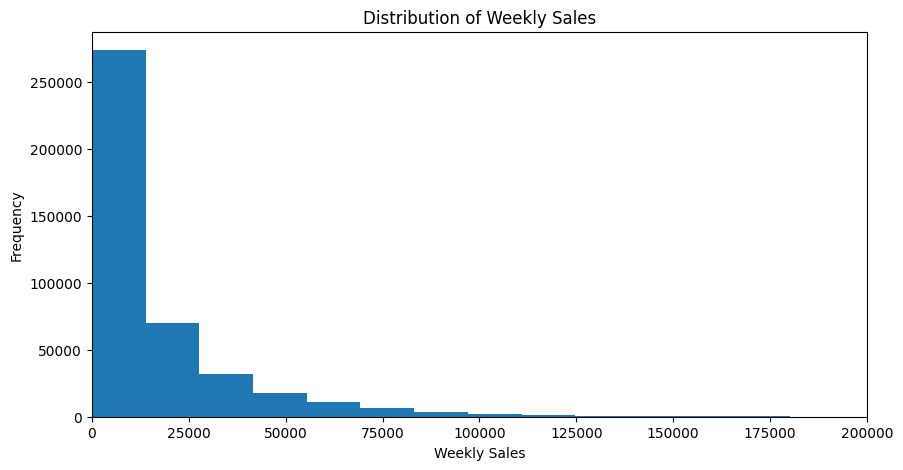

In [17]:
plt.figure(figsize = (10,5))
plt.hist(data['Weekly_Sales'] , bins = 50)
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Weekly Sales")

plt.xlim(0, 200000)
plt.show()

## 4.EDA (Exploratory Data Analysis)

### 1.Boxplot of Weekly Sales

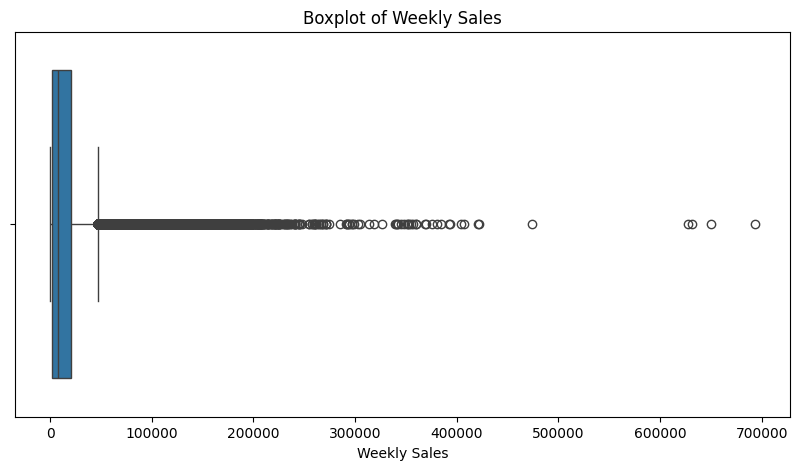

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data['Weekly_Sales'])

plt.xlabel("Weekly Sales")
plt.title("Boxplot of Weekly Sales")

plt.show()

### 2. Top 10 Stores by Revenue

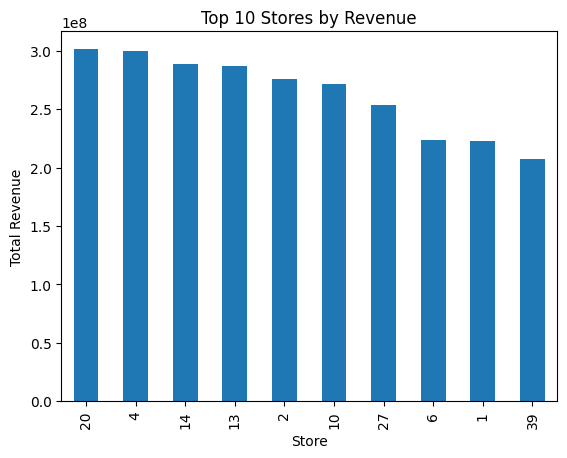

In [19]:
top_stores = (
    data.groupby('Store')['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_stores.plot(kind='bar')
plt.title("Top 10 Stores by Revenue")
plt.xlabel("Store")
plt.ylabel("Total Revenue")
plt.show()

### 3. Top 10 Departments by Revenue

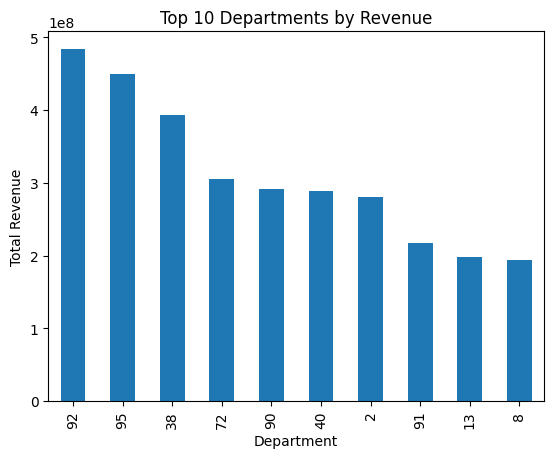

In [20]:
top_dept = (
    data.groupby('Dept')['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_dept.plot(kind='bar')
plt.title("Top 10 Departments by Revenue")
plt.xlabel("Department")
plt.ylabel("Total Revenue")
plt.show()

### 4. Holiday Impact

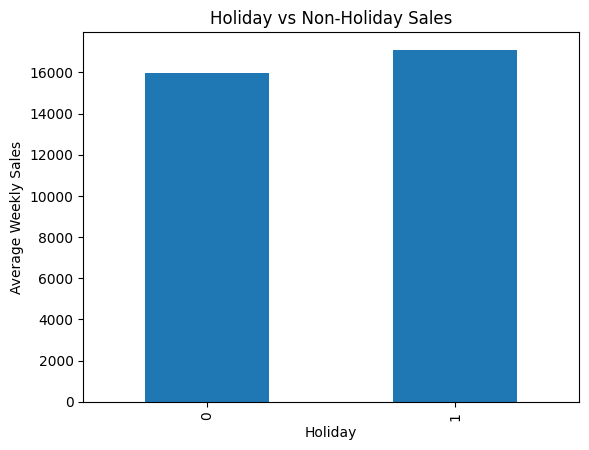

In [21]:
holiday_sales = data.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_sales.plot(kind='bar')

plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday")
plt.ylabel("Average Weekly Sales")

plt.show()

### 5. Monthly Sales Trend

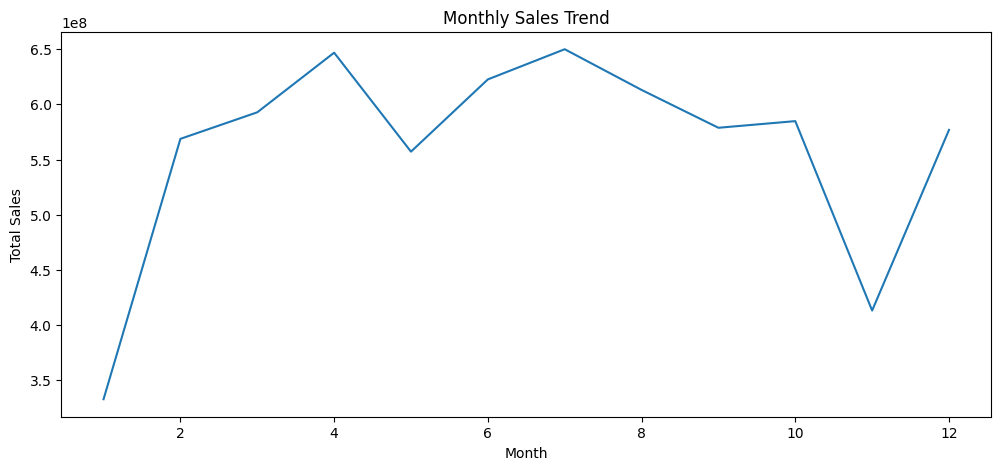

In [22]:
monthly_sales = (
    data.groupby('Month')['Weekly_Sales']
    .sum()
)

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

### 6. Year-wise Trend

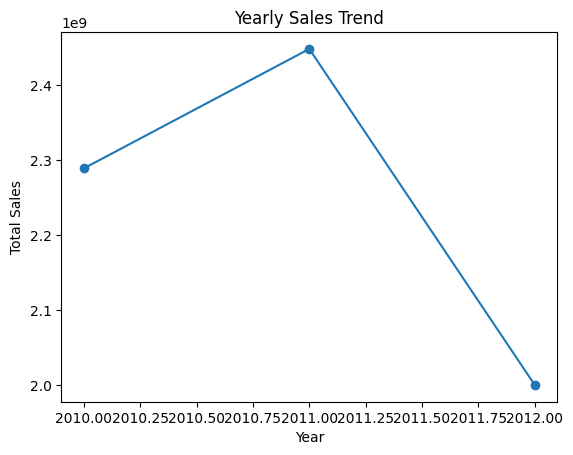

In [23]:
yearly_sales = (
    data.groupby('Year')['Weekly_Sales']
    .sum()
)

yearly_sales.plot(marker='o')

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

## 5.Key Business Insights:

1. Weekly sales exhibit a highly right-skewed distribution, with a small number of observations contributing disproportionately to total revenue.

2. Store 20 emerged as the highest revenue-generating store, followed closely by Stores 4, 14, and 13, indicating strong performance concentration among specific locations.

3. Departments 92, 95, and 38 generated the highest revenues, suggesting that a limited number of departments contribute significantly to overall sales.

4. Holiday periods produce higher average weekly sales than non-holiday periods, highlighting the importance of seasonal inventory planning and promotional strategies.

5. Monthly sales trends reveal clear seasonality, with peak sales occurring around Months 4 and 7, while Month 11 experiences a significant decline.

6. Revenue increased between 2010 and 2011 before declining in 2012, indicating potential market changes or dataset-related factors requiring further investigation.

7. Historical sales patterns, seasonality, store performance, and holiday effects indicate strong potential for predictive sales forecasting and demand planning.


## 6.Data Integration & Feature Enrichment

In [24]:
# Load Additional Datasets
features = pd.read_csv('/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/features.csv')
stores = pd.read_csv('/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/stores.csv')
train = pd.read_csv("/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/train.csv")

#columns of datasets
print(data.columns)
print(features.columns)
print(stores.columns)

# Merge Sales and Features Data
data = pd.merge(
    train,
    features,
    on=['Store','Date','IsHoliday']
)

# Merge Store Information
data = pd.merge(
    data,
    stores,
    on='Store'
)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Year', 'Quarter',
       'Month', 'Week'],
      dtype='object')
Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')
Index(['Store', 'Type', 'Size'], dtype='object')


In [25]:
data.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [27]:
data.duplicated().sum()

np.int64(0)

In [28]:
(data['Weekly_Sales'] < 0).sum()

np.int64(1285)

In [29]:
data = data[data['Weekly_Sales'] > 0]

In [30]:
data['Date'] = pd.to_datetime(data['Date'])

In [31]:
markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

data[markdown_cols] = data[markdown_cols].fillna(0)

In [32]:
data['Type'].unique()

array(['A', 'B', 'C'], dtype=object)

In [33]:
data['Year'] = data['Date'].dt.year
data['Quarter'] = data['Date'].dt.quarter
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week

In [34]:
data.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Quarter,Month,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,1,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,1,2,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,1,2,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,1,2,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,1,3,9


In [35]:
data.shape

(420212, 20)

## 7.Advanced EDA

### 1. Temperature vs Weekly Sales

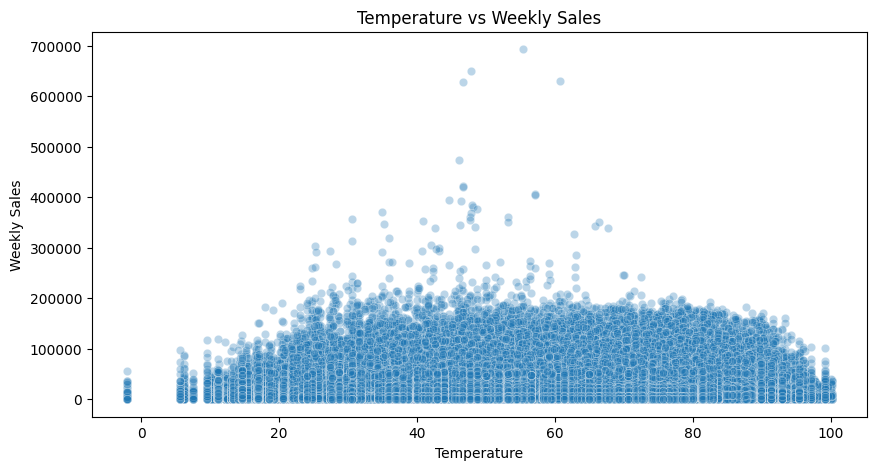

In [36]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Temperature',
    y='Weekly_Sales',
    data=data,
    alpha=0.3
)

plt.title('Temperature vs Weekly Sales')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')

plt.show()

### 2. Fuel Price vs Weekly Sales

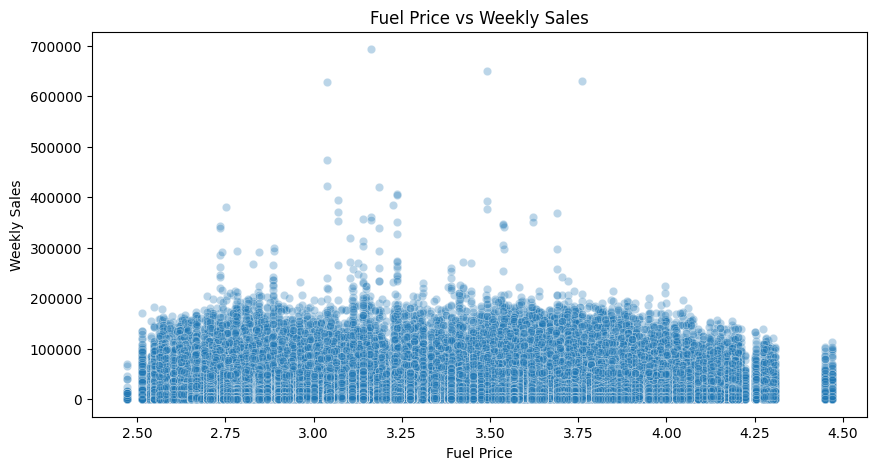

In [37]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Fuel_Price',
    y='Weekly_Sales',
    data=data,
    alpha=0.3
)

plt.title('Fuel Price vs Weekly Sales')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')

plt.show()

### 3. CPI vs Weekly Sales

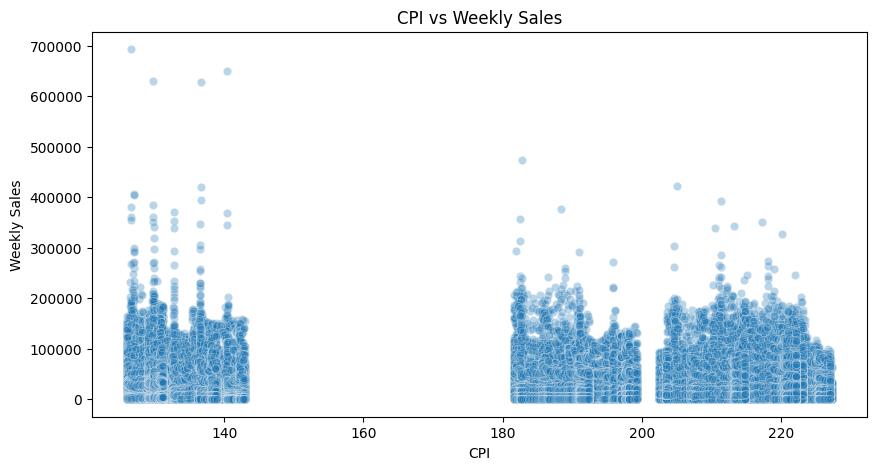

In [38]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='CPI',
    y='Weekly_Sales',
    data=data,
    alpha=0.3
)

plt.title('CPI vs Weekly Sales')
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')

plt.show()

### 4. Unemployment vs Weekly Sales

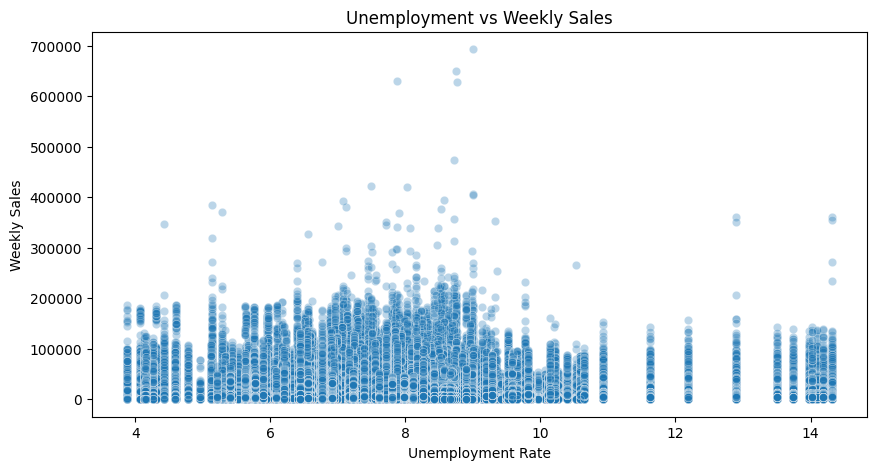

In [39]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Unemployment',
    y='Weekly_Sales',
    data=data,
    alpha=0.3
)

plt.title('Unemployment vs Weekly Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')

plt.show()

### 5. Store Type vs Weekly Sales

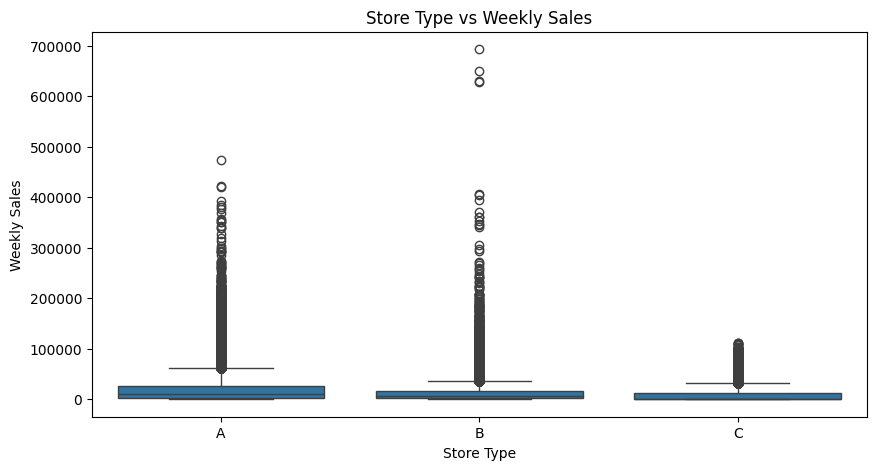

In [40]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Type',
    y='Weekly_Sales',
    data=data
)

plt.title('Store Type vs Weekly Sales')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')

plt.show()

### 6. Store Size vs Weekly Sales

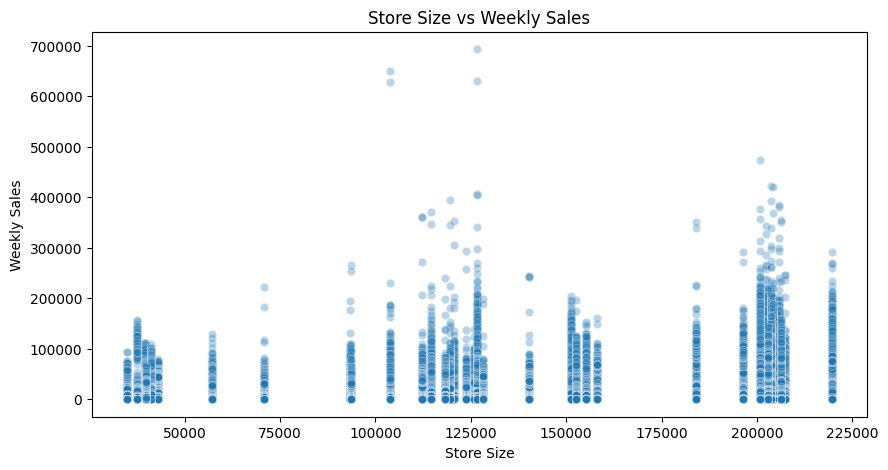

In [41]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Size',
    y='Weekly_Sales',
    data=data,
    alpha=0.3
)

plt.title('Store Size vs Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')

plt.show()

### 7. MarkDown Analysis

In [42]:
data['Total_MarkDown'] = (
    data['MarkDown1'] +
    data['MarkDown2'] +
    data['MarkDown3'] +
    data['MarkDown4'] +
    data['MarkDown5']
)

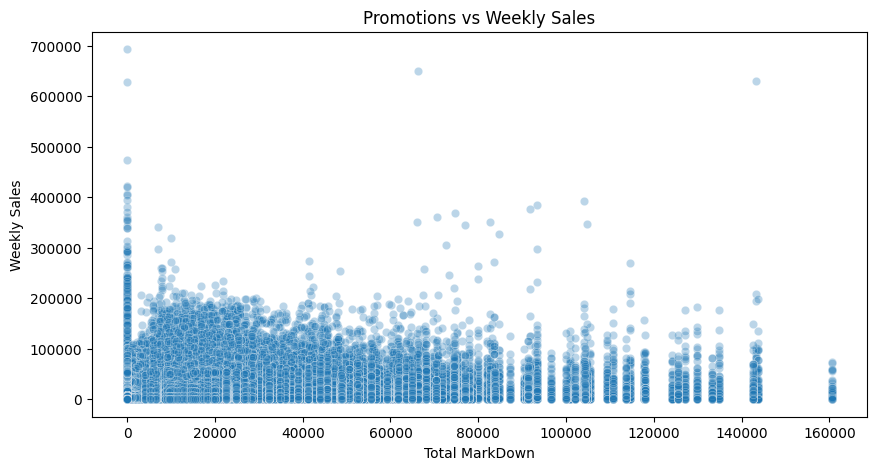

In [43]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Total_MarkDown',
    y='Weekly_Sales',
    data=data,
    alpha=0.3
)

plt.title('Promotions vs Weekly Sales')
plt.xlabel('Total MarkDown')
plt.ylabel('Weekly Sales')

plt.show()

### Correlation Heatmap

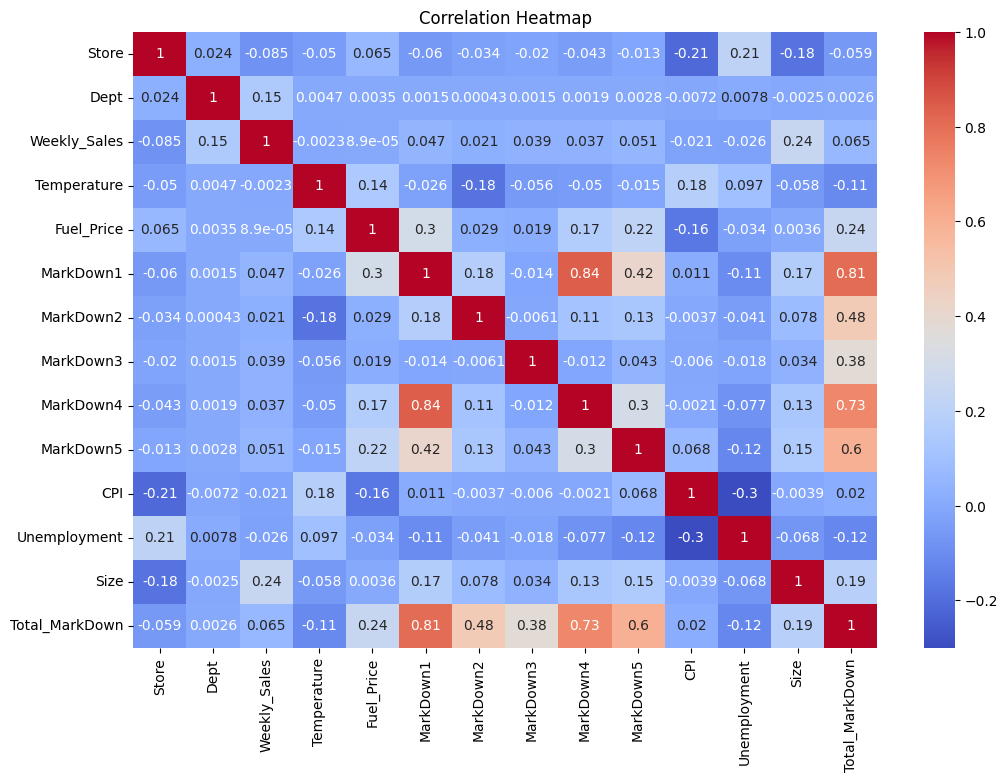

In [44]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## 8.Advanced EDA Insights

 1. Temperature and Sales Relationship

The Temperature vs Weekly Sales analysis shows that high and low sales observations are distributed across nearly all temperature ranges. No clear upward or downward trend is visible.

 Business Insight

Temperature does not appear to be a major factor influencing customer purchasing behavior.

 Recommendation

Temperature should be retained as a supporting feature in forecasting models but should not be considered a primary sales driver.

---

 2. Fuel Price Impact on Sales

The Fuel Price vs Weekly Sales analysis reveals a weak relationship between fuel prices and store sales. Sales remain relatively stable across different fuel price levels.

 Business Insight

Customer demand is not significantly affected by short-term fluctuations in fuel prices.

 Recommendation

Fuel Price may be included in forecasting models but is unlikely to be a high-impact predictor.

---

 3. CPI Impact on Sales

The CPI vs Weekly Sales analysis does not show a strong relationship between inflation levels and weekly sales performance.

 Business Insight

Short-term sales performance appears to be influenced more by operational factors than by inflation changes.

 Recommendation

CPI should be treated as a contextual economic variable rather than a major forecasting feature.

---

 4. Unemployment Impact on Sales

The Unemployment vs Weekly Sales plot indicates that high sales observations become less frequent at higher unemployment levels.

 Business Insight

Rising unemployment may reduce customer spending power and limit sales growth.

 Recommendation

Unemployment should be monitored as an economic risk indicator in long-term forecasting models.

---

 5. Store Type Performance Analysis

Store Type B exhibits the highest sales outliers, with weekly sales approaching $700,000, while Store Type C generally records lower sales volumes.

 Business Insight

Store format significantly affects revenue generation and customer demand patterns.

 Recommendation

Store Type should be included as a key feature in forecasting models and performance evaluation.

---

 6. Store Size Influence on Revenue

The Store Size vs Weekly Sales analysis suggests a positive relationship between store size and revenue generation. Larger stores consistently achieve higher sales volumes.

 Business Insight

Store capacity is an important driver of sales performance.

 Recommendation

Store Size should be considered a critical feature when forecasting future sales and evaluating store expansion opportunities.

---

 7. Promotional Activity Effectiveness

The Promotions vs Weekly Sales analysis indicates that many high-revenue observations occur during periods of increased promotional activity.

 Business Insight

Promotional campaigns contribute to higher customer engagement and increased sales performance.

 Recommendation

Marketing investments should be strategically allocated to promotional campaigns during high-demand periods to maximize revenue.

---

 8. Correlation Analysis Findings

The correlation heatmap highlights that Store Size (0.24) has a stronger relationship with Weekly Sales than Temperature (-0.002), CPI (-0.021), or Unemployment (-0.026).

 Business Insight

Operational factors have a greater impact on revenue generation than external economic variables.

 Recommendation

Forecasting models should prioritize Store Size, Store Type, Promotional Variables, Department, and Seasonal Features over macroeconomic indicators.


## 9.Feature Engineering

### 1. Encode Store Type

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Type'] = le.fit_transform(data['Type'])

### 2. Select Features

In [46]:
features = [
    'Store',
    'Dept',
    'IsHoliday',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Type',
    'Size',
    'Total_MarkDown',
    'Year',
    'Quarter',
    'Month',
    'Week'
]

target = 'Weekly_Sales'

### 3. Create X and y

In [47]:
X = data[features]
y = data[target]

### 4. Train-Test Split

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 10.Sales Forecasting Models

### 1.Linear Regression

In [49]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

MAE: 14516.536957172126
RMSE: 21546.71680703354
R2: 0.09112000517377239


### 2.Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [52]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 1432.875396122223
RMSE: 3447.974822248369
R2: 0.9767259207526789


In [53]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'R² Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
}).round(2)

comparison.style.highlight_max(
    subset=['R² Score'],
    color='lightgreen'
).highlight_min(
    subset=['MAE', 'RMSE'],
    color='lightgreen'
)

,Model,MAE,RMSE,R² Score
0,Linear Regression,14516.540000,21546.720000,0.090000
1,Random Forest,1432.880000,3447.970000,0.980000


## 11.Feature Importance Analysis

In [54]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

           Feature  Importance
1             Dept    0.629023
8             Size    0.187558
0            Store    0.059066
13            Week    0.042258
5              CPI    0.026845
7             Type    0.014009
6     Unemployment    0.011341
3      Temperature    0.011208
12           Month    0.007531
4       Fuel_Price    0.005468
9   Total_MarkDown    0.003552
2        IsHoliday    0.001506
10            Year    0.000397
11         Quarter    0.000238


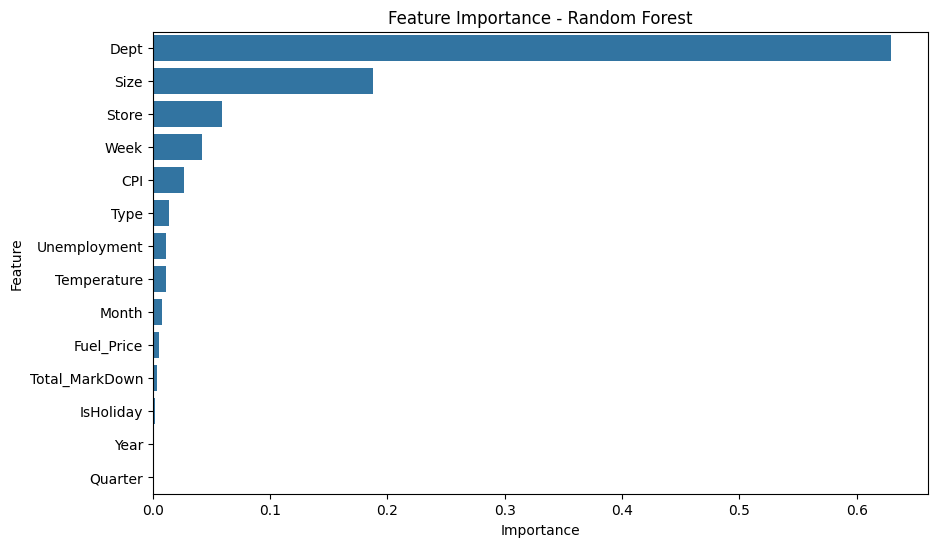

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

### Model Evaluation & Comparison

Linear Regression achieved an R² score of 0.09, indicating limited ability to capture complex sales patterns. Random Forest significantly outperformed Linear Regression, achieving an R² score of 0.98 while reducing prediction error substantially. Therefore, Random Forest was selected as the final forecasting model for deployment.

### Actual vs Predicted Plot

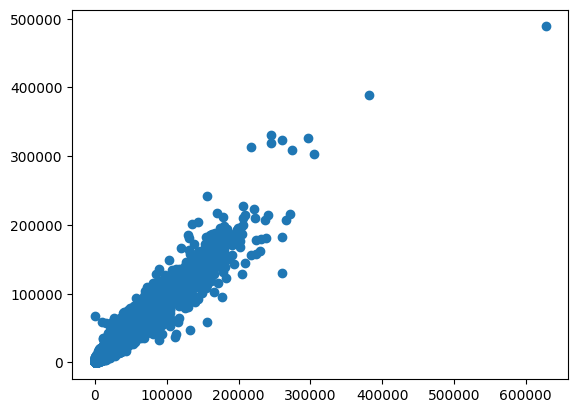

In [56]:
plt.scatter(y_test, y_pred_rf)

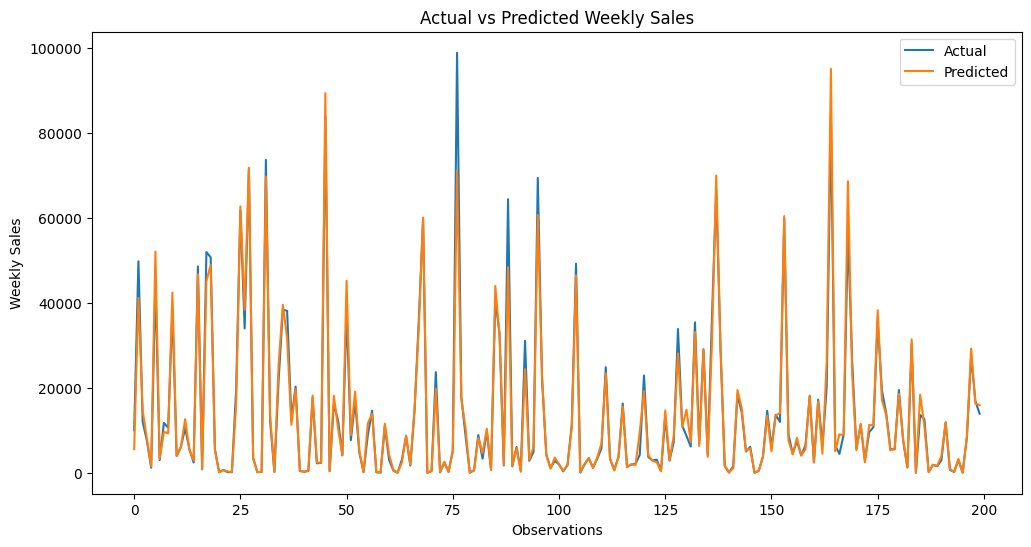

In [57]:
sample = pd.DataFrame({
    'Actual': y_test.values[:200],
    'Predicted': y_pred_rf[:200]
})

plt.figure(figsize=(12,6))

plt.plot(sample['Actual'].values, label='Actual')
plt.plot(sample['Predicted'].values, label='Predicted')

plt.title('Actual vs Predicted Weekly Sales')
plt.xlabel('Observations')
plt.ylabel('Weekly Sales')
plt.legend()

plt.show()

### Residual Distribution Plot

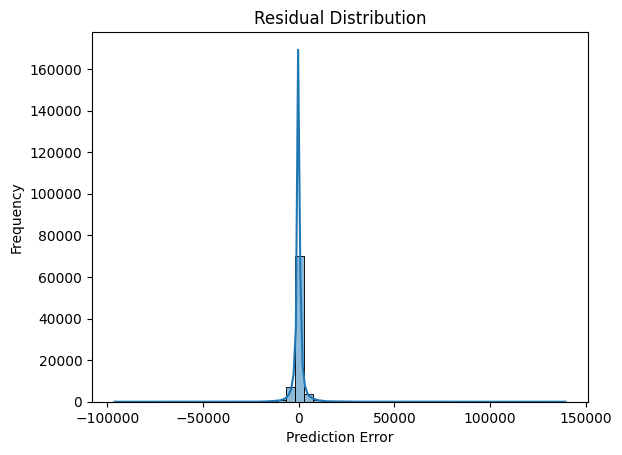

In [58]:
residuals = y_test - y_pred_rf

sns.histplot(residuals, bins=50, kde=True)

plt.title('Residual Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')

plt.show()

## 12.Strategic Recommendations:

### 1. Prioritize High-Revenue Departments

Department contributes approximately 63% of the model's predictive power, making it the single most important driver of weekly sales.

 Recommendation

Allocate inventory, shelf space, and promotional budgets preferentially to high-performing departments. Department-level demand forecasting should be implemented to reduce stockout risk and improve product availability.

---

### 2. Optimize Inventory Based on Store Size

Store Size emerged as the second most influential sales driver, accounting for nearly 19% of feature importance.

 Recommendation

Inventory allocation should be customized according to store capacity rather than applying uniform stocking policies across all stores. Larger stores should receive higher inventory allocations due to their greater revenue-generating potential.

---

### 3. Implement Store-Specific Sales Planning

Store identity contributes more to sales performance than most economic indicators.

 Recommendation

Develop store-level forecasting and inventory strategies instead of relying solely on company-wide demand estimates. High-performing stores should be managed separately to maximize revenue opportunities.

---

### 4. Improve Weekly Demand Forecasting

Week-based features contribute significantly to sales prediction, indicating recurring demand patterns throughout the year.

 Recommendation

Adopt rolling weekly forecasting processes to improve inventory planning, workforce scheduling, and replenishment decisions.

---

### 5. Shift Focus from Economic Indicators to Operational Factors

Temperature, Fuel Price, CPI, and Unemployment show limited influence on sales performance compared to internal business variables.

 Recommendation

Management should prioritize operational decisions such as assortment planning, inventory optimization, and department performance management rather than reacting heavily to short-term economic fluctuations.

---

### 6. Develop Department-Level Forecasting Models

The dominance of Department as a predictive feature suggests that customer demand varies significantly across product categories.

 Recommendation

Build separate forecasting models for major departments to improve forecast accuracy and support more targeted inventory management.

---

### 7. Establish a Data-Driven Inventory Optimization System

The Random Forest model achieved an R² score of 0.98, demonstrating strong forecasting capability.

 Recommendation

Deploy the forecasting system to support procurement planning, inventory optimization, staffing decisions, and revenue forecasting. This can help reduce excess inventory while maintaining product availability during peak demand periods.

---

### 8. Focus Management Attention on Key Revenue Drivers

Feature importance analysis shows that Department, Store Size, Store, and Week account for the majority of sales variability.

 Recommendation

Future business strategies should concentrate on these core operational drivers, as improvements in these areas are likely to generate the greatest impact on revenue growth.


## 13.Conclusion:
This project analyzed Walmart's historical sales data to identify key factors influencing retail sales and develop an accurate sales forecasting model. Through data analysis, feature engineering, and machine learning, important sales drivers such as Department, Store Size, Store, and seasonal patterns were identified.

Among the evaluated models, Random Forest achieved the best performance with an R² score of 0.98, significantly outperforming Linear Regression. The results demonstrate that machine learning can effectively support demand forecasting, inventory planning, and data-driven business decision-making in the retail industry.

In [59]:
data.to_csv("walmart_final.csv", index=False)